# Постановка задачи

Численно решить уравнение переноса с неоднородной скоростью:

\begin{cases}
u_t + v(x) u_x = 0, \quad 0 < t, \quad 0 < x < l, \\
u(x, t) = u(x + l, t), \\
u(x, 0) = \varphi(x).
\end{cases}

где

$$
v(x) = a\left(1 + 3\sin^2\frac{\pi n x}{l}\right), \quad n \in \mathbb{N}.
$$

## Точное решение

$$
u_0(x, t) = \varphi\left(\left[\frac{l}{\pi n} \chi^{-1}\left(\chi\left(\frac{\pi n x}{l}\right) - \frac{\pi n a t}{l}\right)\right]_l\right), \quad [\cdot]_l - \text{остаток от деления на } l.
$$

где

$$
\chi(x) = \int_{0}^{x} \frac{d\xi}{1 + 3\sin^2\xi} = \frac{1}{2}\arctan(2\tan x) + \frac{1}{2}(x)_\pi
$$

$$
\chi^{-1}(x) = \arctan\left(\frac{1}{2}\tan 2x\right) + (2x)_\pi, \quad (\cdot)_\pi - \text{округление до числа, кратного $\pi$}.
$$

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [ ]:
a = 1.0
l = 2.0
n = 2
T = 0.2

h = 0.01
tau = 0.001

In [ ]:
def v(x):
    return a * (1 + 3 * np.sin(np.pi * n * x / l)**2)

def heaviside(x):
    return np.where(x < 0, 0.0, np.where(x == 0, 0.5, 1.0))

def phi1(x, x0=l/2, epsilon=0.3):
    xi = np.abs(x - x0) / epsilon
    return heaviside(1 - xi)

def phi3(x, x0=l/2, epsilon=0.3):
    xi = np.abs(x - x0) / epsilon
    phi3 = phi1(x, x0, epsilon) * np.cos(np.pi * xi / 2) ** 3
    return phi3

current_phi = phi3

def phi(x):
    return current_phi(x)

def round_to_pi(x):
    return np.round(x / np.pi) * np.pi

def chi(x):
    return 0.5 * np.arctan(2 * np.tan(x)) + 0.5 * round_to_pi(x)

def chi_inv(x):
    return np.arctan(0.5 * np.tan(2 * x)) + round_to_pi(2 * x)

def u_exact(x, t):
    arg = chi(np.pi * n * x / l) - np.pi * n * a * t / l
    x_new = l / (np.pi * n) * chi_inv(arg)
    x_new = x_new % l
    return phi(x_new)

In [ ]:
def solve_lax_wendroff():
    global h, tau

    Nx = int(round(l / h))
    Nt = int(round(T / tau)) + 1

    h_actual = l / Nx
    tau_actual = T / (Nt - 1)

    x_calc = np.linspace(0, l, Nx, endpoint=False)
    t = np.linspace(0, T, Nt)

    U = phi(x_calc)
    velocity = v(x_calc)
    CFL = tau_actual * velocity / h_actual

    if np.max(CFL) >= 1.0:
        print(f"ВНИМАНИЕ! Нарушено условие Куранта: max(CFL) = {np.max(CFL):.2f}")

    x_full = np.append(x_calc, l)

    yield x_full, t[0], np.append(U, U[0])

    v_ip1 = np.roll(velocity, -1)
    v_im1 = np.roll(velocity, 1)
    v_half_plus = 0.5 * (velocity + v_ip1)
    v_half_minus = 0.5 * (velocity + v_im1)

    for i in range(1, Nt):
        U_ip1 = np.roll(U, -1)
        U_im1 = np.roll(U, 1)

        term1 = 0.5 * CFL * (U_ip1 - U_im1)
        term2 = 0.5 * CFL * (tau_actual / h_actual) * (
            v_half_plus * (U_ip1 - U) - v_half_minus * (U - U_im1)
        )

        U = U - term1 + term2

        yield x_full, t[i], np.append(U, U[0])

In [ ]:
def convergence_analysis(solve_gen):
    global h, tau, current_phi, v, u_exact

    original_v = v
    original_phi = current_phi
    original_u_exact = u_exact
    old_h = h
    old_tau = tau

    test_c = 1.0

    def mock_v(x):
        return np.full_like(x, test_c)

    def mock_phi(x):
        return np.sin(2 * np.pi * x / l)

    def mock_u_exact(x, t):
        return np.sin(2 * np.pi * (x - test_c * t) / l)

    try:
        v = mock_v
        current_phi = mock_phi
        u_exact = mock_u_exact

        CFL_target = 0.3

        print("Эксперимент 1: Сходимость по h (CFL фиксирован = 0.3)")
        h_list1 = [0.04, 0.02, 0.01, 0.005]
        tau_list1 = [CFL_target * h_val / test_c for h_val in h_list1]

        errors_h = []
        for h_val, tau_val in zip(h_list1, tau_list1):
            h, tau = h_val, tau_val

            for x_val, t_val, U_num in solve_gen():
                pass

            U_true = u_exact(x_val, t_val)
            error = np.sqrt(np.sum((U_num - U_true)**2)) / np.sqrt(np.sum(U_true**2))
            errors_h.append(error)

        print("Эксперимент 2: Сходимость по tau (h фиксировано = 0.002)")
        h_fixed = 0.002
        tau_list2 = [0.0004, 0.0002, 0.0001, 0.00005]

        errors_tau = []
        for tau_val in tau_list2:
            h, tau = h_fixed, tau_val

            for x_val, t_val, U_num in solve_gen():
                pass

            U_true = u_exact(x_val, t_val)
            error = np.sqrt(np.sum((U_num - U_true)**2)) / np.sqrt(np.sum(U_true**2))
            errors_tau.append(error)

    finally:
        v = original_v
        current_phi = original_phi
        u_exact = original_u_exact
        h = old_h
        tau = old_tau

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.loglog(h_list1, errors_h, 'bo-', linewidth=2, markersize=8)
    h_ref = np.array(h_list1)
    plt.loglog(h_ref, errors_h[0] * (h_ref/h_list1[0])**2, 'r--', alpha=0.5, label='Эталон $O(h^2)$')
    plt.xlabel('Шаг $h$')
    plt.ylabel('Относительная ошибка $L_2$')
    plt.title('Сходимость по $h$')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_h = [np.log(errors_h[i-1]/errors_h[i]) / np.log(h_list1[i-1]/h_list1[i]) for i in range(1, len(errors_h))]
    print(f"Порядки по h: {[f'{o:.2f}' for o in orders_h]}")

    plt.subplot(1, 2, 2)
    plt.loglog(tau_list2, errors_tau, 'bo-', linewidth=2, markersize=8)
    tau_ref = np.array(tau_list2)
    plt.loglog(tau_ref, errors_tau[0] * (tau_ref/tau_list2[0])**2, 'r--', alpha=0.5, label='Эталон $O(\\tau^2)$')
    plt.xlabel('Шаг $\\tau$')
    plt.ylabel('Относительная ошибка $L_2$')
    plt.title('Сходимость по $\\tau$')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_tau = [np.log(errors_tau[i-1]/errors_tau[i]) / np.log(tau_list2[i-1]/tau_list2[i]) for i in range(1, len(errors_tau))]
    print(f"Порядки по tau: {[f'{o:.2f}' for o in orders_tau]}\n")

    plt.tight_layout()
    plt.show()


Эксперимент 1: Сходимость по h (CFL фиксирован = 0.3)
Эксперимент 2: Сходимость по tau (h фиксировано = 0.002)
Порядки по h: ['2.01', '2.00', '2.00']
Порядки по tau: ['-0.04', '-0.01', '-0.00']



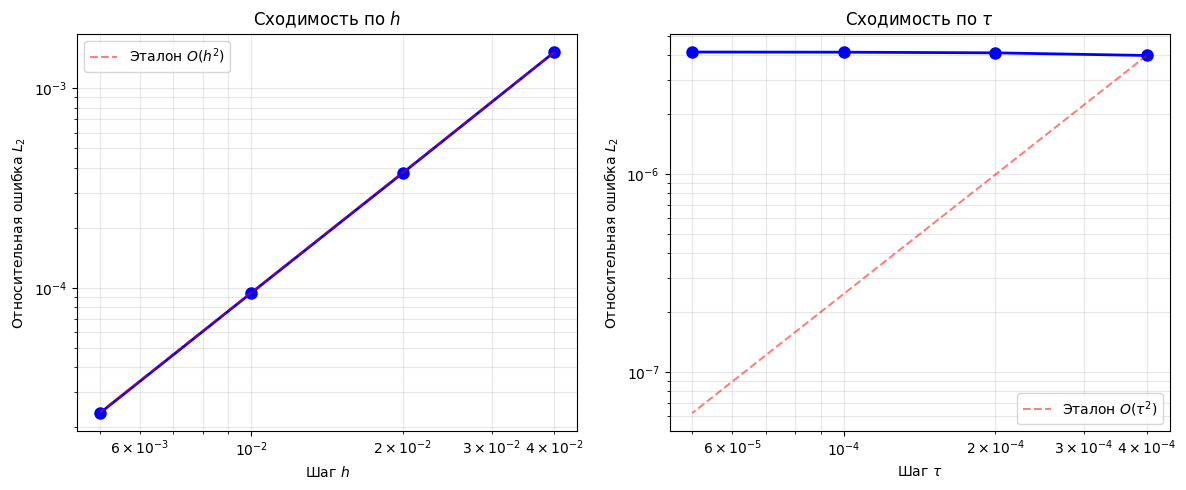

In [ ]:
convergence_analysis(solve_lax_wendroff)

In [ ]:
def convergence_analysis(solve_gen):
    global h, tau

    v_max = np.max(v(np.linspace(0, l, 1000)))
    CFL_target = 0.3

    old_h = h
    old_tau = tau

    print("Эксперимент 1: Сходимость по h (CFL фиксирован = 0.3)")
    h_list1 = [0.04, 0.02, 0.01, 0.005]
    tau_list1 = [CFL_target * h_val / v_max for h_val in h_list1]

    errors_h = []
    for h_val, tau_val in zip(h_list1, tau_list1):
        h = h_val
        tau = tau_val

        for x_val, t_val, U_num in solve_gen():
            pass

        U_true = u_exact(x_val, t_val)

        mask = (x_val >= 0.0) & (x_val <= 1.3)
        error = np.mean(np.abs(U_num[mask] - U_true[mask])**2)
        errors_h.append(error)

    print("Эксперимент 2: Сходимость по tau (h фиксировано = 0.002)")
    h_fixed = 0.002
    tau_list2 = [0.0004, 0.0002, 0.0001, 0.00005]

    errors_tau = []
    for tau_val in tau_list2:
        h = h_fixed
        tau = tau_val

        for x_val, t_val, U_num in solve_gen():
            pass

        U_true = u_exact(x_val, t_val)

        mask = (x_val >= 0.0) & (x_val <= 1.4)
        error = np.sqrt(np.sum((U_num[mask] - U_true[mask])**2))
        errors_tau.append(error)

    h = old_h
    tau = old_tau

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.loglog(h_list1, errors_h, 'bo-', linewidth=2, markersize=8)
    h_ref = np.array(h_list1)
    plt.loglog(h_ref, errors_h[0] * (h_ref/h_list1[0])**2, 'r--', alpha=0.5, label='O(h^2)')
    plt.xlabel('h')
    plt.ylabel('Error L2')
    plt.title('Сходимость по h')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_h = [np.log(errors_h[i-1]/errors_h[i]) / np.log(h_list1[i-1]/h_list1[i]) for i in range(1, len(errors_h))]
    print(f"Порядки по h: {[f'{o:.2f}' for o in orders_h]}")

    plt.subplot(1, 2, 2)
    plt.loglog(tau_list2, errors_tau, 'bo-', linewidth=2, markersize=8)
    tau_ref = np.array(tau_list2)
    plt.loglog(tau_ref, errors_tau[0] * (tau_ref/tau_list2[0])**2, 'r--', alpha=0.5, label='O(tau^2)')
    plt.xlabel('tau')
    plt.ylabel('Error L2')
    plt.title('Сходимость по tau')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    orders_tau = [np.log(errors_tau[i-1]/errors_tau[i]) / np.log(tau_list2[i-1]/tau_list2[i]) for i in range(1, len(errors_tau))]
    print(f"Порядки по tau: {[f'{o:.2f}' for o in orders_tau]}\n")

    plt.tight_layout()
    plt.show()

Эксперимент 1: Сходимость по h (CFL фиксирован = 0.3)
Эксперимент 2: Сходимость по tau (h фиксировано = 0.002)
Порядки по h: ['1.53', '1.74', '1.88']
Порядки по tau: ['-0.06', '-0.02', '-0.00']



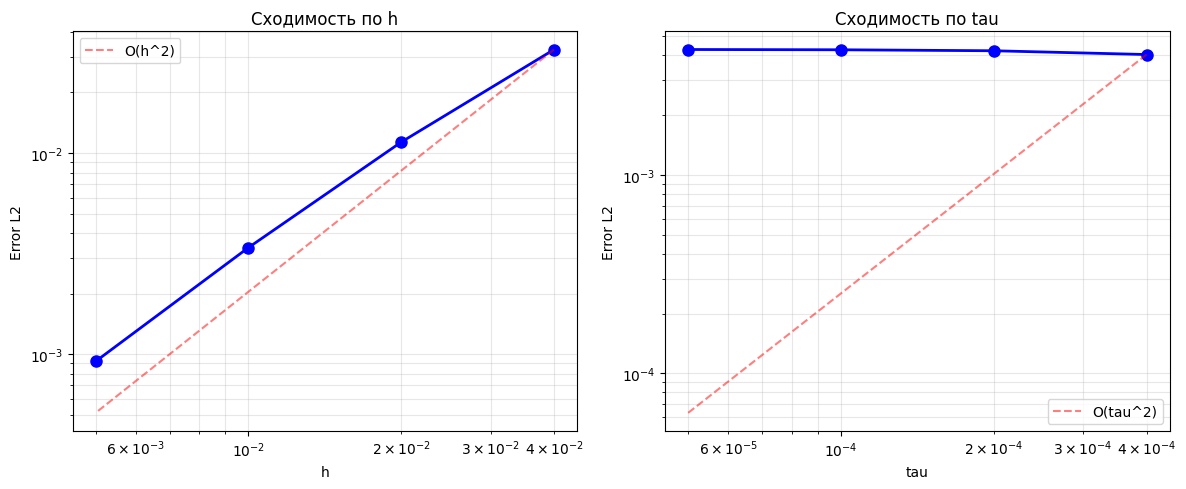

In [ ]:
convergence_analysis(solve_lax_wendroff)

In [ ]:
def animate_solution_simple(solve_gen_func, title_text="Лакс-Вендрофф", filename=None, frame_skip=20):
    print(f"[{title_text}] Расчет и сборка кадров...")
    frames_U, frames_t = [], []
    x = None

    step = 0
    for x_val, t_val, U_val in solve_gen_func():
        if step % frame_skip == 0:
            if x is None: x = x_val
            frames_U.append(U_val)
            frames_t.append(t_val)
        step += 1

    print(f"Готово. Собрано кадров для анимации: {len(frames_U)}")

    fig, ax = plt.subplots(figsize=(10, 6))
    line_num, = ax.plot(x, frames_U[0], 'b-', lw=2, label='Численное (Лакс-Вендрофф)')
    line_exact, = ax.plot(x, u_exact(x, frames_t[0]), 'r--', lw=2, alpha=0.7, label='Точное')

    ax.set_xlabel('x')
    ax.set_ylabel('U(x,t)')
    ax.set_title(title_text)
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.legend(loc='upper right')
    ax.set_xlim(0, l)
    ax.set_ylim(-0.5, 1.5)

    time_text = ax.text(0.02, 0.94, '', transform=ax.transAxes, fontsize=12,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    def update(frame_idx):
        line_num.set_ydata(frames_U[frame_idx])
        line_exact.set_ydata(u_exact(x, frames_t[frame_idx]))
        time_text.set_text(f't = {frames_t[frame_idx]:.3f} c')
        return line_num, line_exact, time_text

    anim = animation.FuncAnimation(fig, update, frames=len(frames_U),
                                   interval=40, blit=True)

    if filename:
        print(f"Сохранение в файл {filename}...")
        anim.save(filename, writer='ffmpeg', fps=25, dpi=120)
        print("Успешно сохранено.")

    plt.show()
    return anim

[Лакс-Вендрофф (Гладкое решение)] Расчет и сборка кадров...
Готово. Собрано кадров для анимации: 21
Сохранение в файл smooth-animation.mp4...
Успешно сохранено.


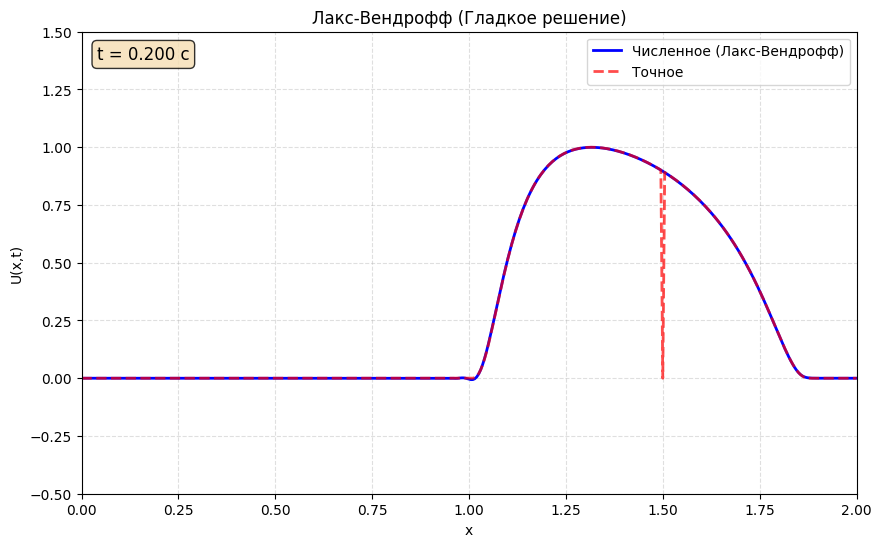

[Лакс-Вендрофф (Осцилляции на разрыве)] Расчет и сборка кадров...
Готово. Собрано кадров для анимации: 21
Сохранение в файл notsmooth-animation.mp4...
Успешно сохранено.


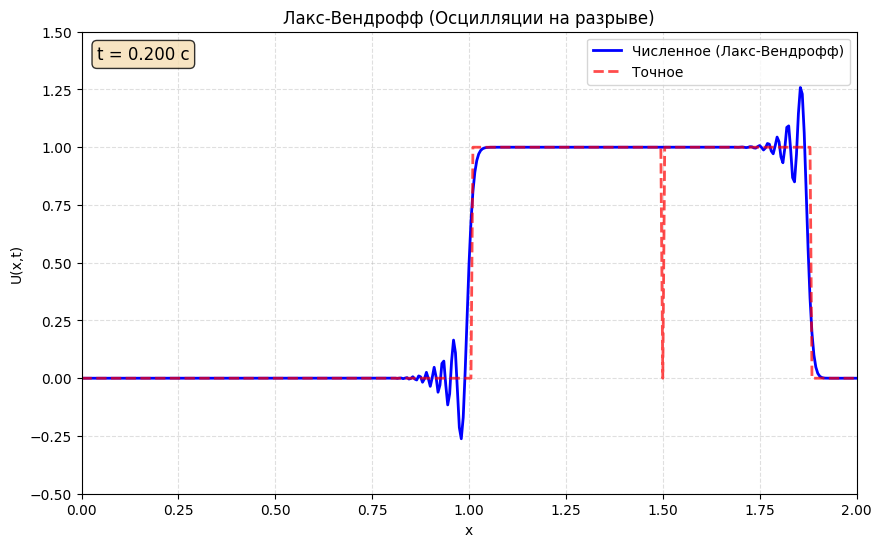

In [ ]:
h = 0.005
tau = 0.0005

current_phi = phi3
anim1 = animate_solution_simple(
    solve_lax_wendroff,
    filename="smooth-animation.mp4",
    title_text="Лакс-Вендрофф (Гладкое решение)",
    frame_skip=20
)

current_phi = phi1
anim2 = animate_solution_simple(
    solve_lax_wendroff,
    filename="notsmooth-animation.mp4",
    title_text="Лакс-Вендрофф (Осцилляции на разрыве)",
    frame_skip=20
)